
# SigFeatX Playground

This notebook is a live demonstration, not a polished write-up: every number
and image below is computed in this run, on one signal, using nothing but
the public `SigFeatX` API.

The idea is simple. A feature-extraction library is only as trustworthy as
its math is correct, so rather than *claim* the decompositions reconstruct
correctly, this notebook **shows the reconstruction error for every method**,
side by side, on the same signal. Then it runs every feature family the
library ships, and finally checks that a handful of well-known features
(Hurst exponent, DFA, spectral entropy...) land where signal-processing
theory says they should on white noise versus a clean periodic signal.

**Contents**
1. The test signal
2. Decompose &rarr; reconstruct, for every decomposition method
3. Reconstruction accuracy, side by side
4. Time-frequency / spectral analysis methods
5. Feature extraction: every family, one signal
6. Mini experiment: do the features make physical sense?
7. A closer look: RQA recurrence plot & MFDFA multifractal spectrum


In [1]:

import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

from SigFeatX.decompose import (
    EMD, CEEMDAN, VMD, SVMD, EFD, LMD, JMD, WaveletDecomposer, MODWT, HHT, SST,
    FourierTransform, ShortTimeFourierTransform,
)
from SigFeatX.features.features import (
    TimeDomainFeatures, FrequencyDomainFeatures, EntropyFeatures, NonlinearFeatures,
)
from SigFeatX.features.rqa import RQAFeatures
from SigFeatX.features.mfdfa import MFDFAFeatures
from SigFeatX.features.advanced_entropy import AdvancedEntropyFeatures

warnings.filterwarnings("ignore")
%matplotlib inline


## Style

One consistent, colorblind-checked palette for every figure in this notebook: a fixed-order categorical set for component identity, and a single-hue sequential ramp for heatmaps (never a rainbow colormap).

In [2]:

CATEGORICAL = ['#2a78d6', '#1baf7a', '#eda100', '#008300',
               '#4a3aa7', '#e34948', '#e87ba4', '#eb6834']
INK_PRIMARY   = '#0b0b0b'
INK_SECONDARY = '#52514e'
INK_MUTED     = '#898781'
GRID          = '#e1e0d9'
SURFACE       = '#fcfcfb'

SEQ_BLUE = LinearSegmentedColormap.from_list(
    'seq_blue', ['#cde2fb', '#9ec5f4', '#6da7ec', '#3987e5', '#256abf', '#184f95', '#0d366b']
)

plt.rcParams.update({
    'figure.facecolor': SURFACE,
    'axes.facecolor': SURFACE,
    'axes.edgecolor': GRID,
    'axes.labelcolor': INK_SECONDARY,
    'axes.grid': True,
    'grid.color': GRID,
    'grid.linewidth': 0.8,
    'text.color': INK_PRIMARY,
    'xtick.color': INK_MUTED,
    'ytick.color': INK_MUTED,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10,
    'figure.dpi': 100,
})


def component_color(i):
    return CATEGORICAL[i % len(CATEGORICAL)]



## 1. The test signal

A synthetic multi-band signal: three sinusoids at 2, 10, and 22&nbsp;Hz
(loosely echoing the theta/alpha/beta bands this library is often used for
in EEG work) plus a touch of Gaussian noise, at a biomedical-typical 250&nbsp;Hz
sampling rate. Nothing exotic &mdash; a fair, common test bed every method
below gets a shot at.


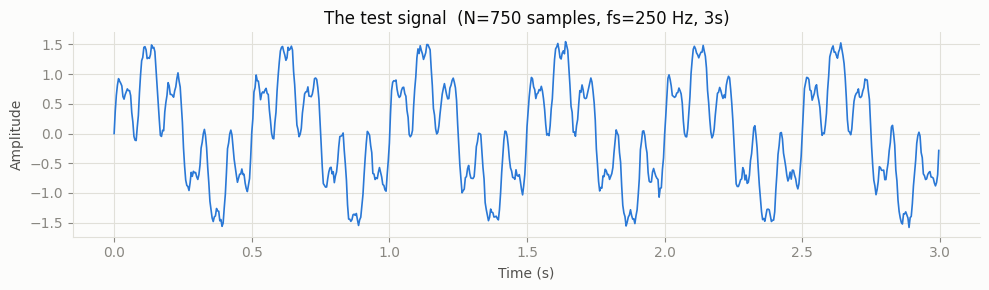

std=0.8525   peak-to-peak=3.1270


In [3]:

rng = np.random.default_rng(7)
fs = 250.0
duration = 3.0
t = np.arange(0, duration, 1 / fs)
N = len(t)

signal = (
    1.0 * np.sin(2 * np.pi * 2.0 * t)
    + 0.6 * np.sin(2 * np.pi * 10.0 * t)
    + 0.3 * np.sin(2 * np.pi * 22.0 * t)
    + 0.05 * rng.standard_normal(N)
)

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(t, signal, color=CATEGORICAL[0], lw=1.2)
ax.set_title(f'The test signal  (N={N} samples, fs={fs:.0f} Hz, {duration:.0f}s)')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Amplitude')
plt.tight_layout()
plt.show()

print(f"std={np.std(signal):.4f}   peak-to-peak={np.ptp(signal):.4f}")



## 2. Decompose &rarr; reconstruct

For each method: decompose the signal into components, sum them back, and
plot original vs. reconstructed directly on top of each other &mdash; if the
library is correct, you should not be able to tell them apart. The
reconstruction error (RMSE, and as a percentage of the signal's own standard
deviation) is printed for every method, not just claimed.

EMD, CEEMDAN, SVMD, LMD, DWT, and MODWT decompose by explicit residual
subtraction, so perfect reconstruction is a hard mathematical guarantee, not
a fitted approximation. VMD and JMD are *variational* methods (they fit
modes to a bandwidth-constrained optimisation objective rather than peeling
off an explicit residual), so a small reconstruction error is expected and
normal for that family &mdash; it's called out explicitly rather than
hidden.


In [4]:

results = []

def show_decomposition(name, components, reconstructed, elapsed, note=""):
    n = min(len(reconstructed), len(signal))
    err = np.sqrt(np.mean((reconstructed[:n] - signal[:n]) ** 2))
    rel = 100 * err / np.std(signal)
    results.append(dict(method=name, n_components=len(components), rmse=err,
                         rel_rmse_pct=rel, seconds=elapsed))

    _fig, axes = plt.subplots(2, 1, figsize=(10, 5), height_ratios=[1.3, 1])

    ax = axes[0]
    ax.plot(t, signal, color=INK_MUTED, lw=2.5, label='original', alpha=0.6)
    ax.plot(t[:n], reconstructed[:n], color=CATEGORICAL[0], lw=1, label='reconstructed')
    ax.set_title(f'{name}  —  {len(components)} components  —  '
                 f'RMSE={err:.2e} ({rel:.2f}% of signal std)  —  {elapsed:.3f}s'
                 + (f'  —  {note}' if note else ''))
    ax.legend(loc='upper right', frameon=False)
    ax.set_ylabel('Amplitude')

    ax = axes[1]
    for i, comp in enumerate(components):
        # Some methods (e.g. decimated DWT) return shorter coefficient
        # arrays per level; space them across the full duration rather
        # than the first len(comp) samples, or a downsampled level would
        # misleadingly look like it only covers the start of the signal.
        comp_t = np.linspace(0, duration, len(comp))
        ax.plot(comp_t, comp + i * (2.2 * np.std(signal)),
                color=component_color(i), lw=0.9)
    ax.set_yticks([])
    ax.set_xlabel('Time (s)')
    ax.set_xlim(0, duration)
    ax.set_title('components (stacked, offset for visibility)', fontsize=9, color=INK_SECONDARY)

    plt.tight_layout()
    plt.show()


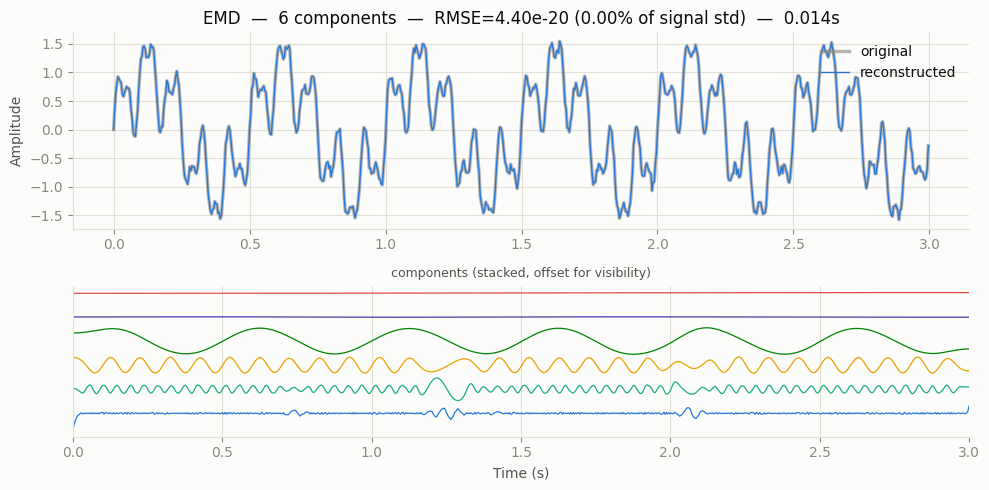

In [5]:

t0 = time.perf_counter()
emd = EMD(max_imf=6)
imfs = emd.decompose(signal)
rec = emd.reconstruct(imfs)
show_decomposition('EMD', imfs, rec, time.perf_counter() - t0)


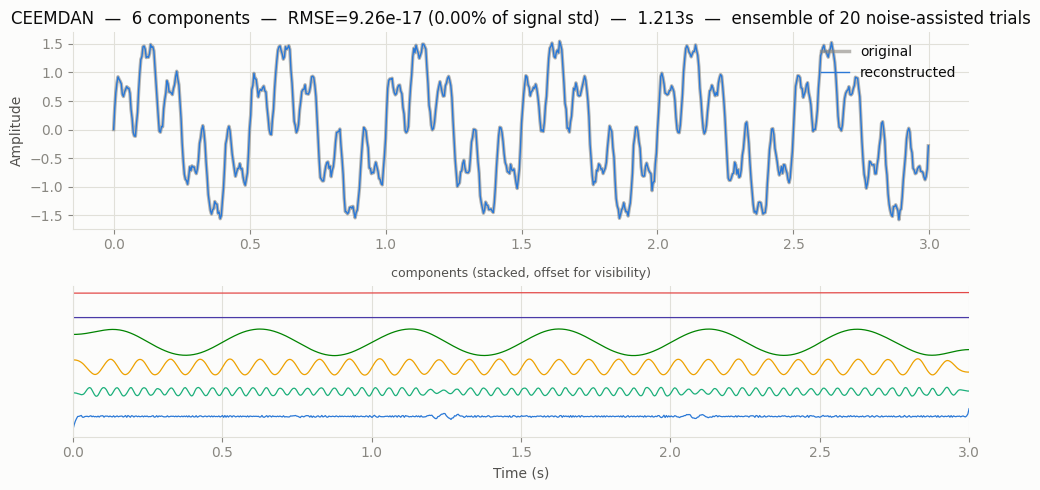

In [6]:

t0 = time.perf_counter()
ceemdan = CEEMDAN(trials=20, max_imf=5, rng=0)
imfs = ceemdan.decompose(signal)
rec = ceemdan.reconstruct(imfs)
show_decomposition('CEEMDAN', imfs, rec, time.perf_counter() - t0,
                    note='ensemble of 20 noise-assisted trials')


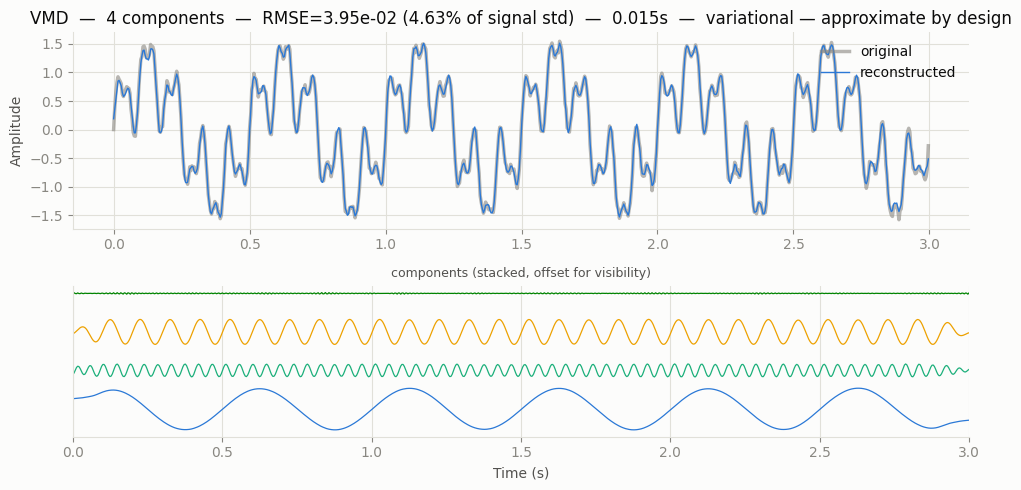

In [7]:

t0 = time.perf_counter()
vmd = VMD(K=4)
modes = vmd.decompose(signal)
rec = vmd.reconstruct(modes)
show_decomposition('VMD', list(modes), rec, time.perf_counter() - t0,
                    note='variational — approximate by design')


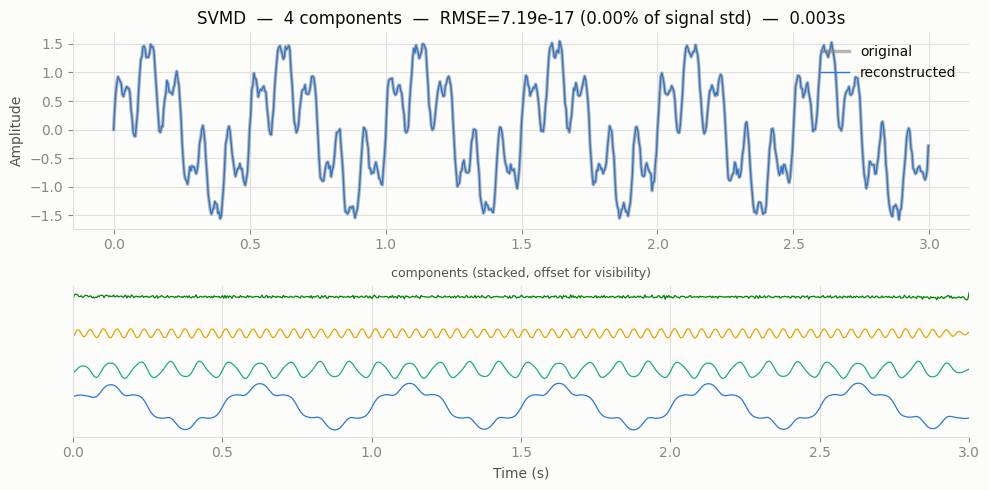

In [8]:

t0 = time.perf_counter()
svmd = SVMD(K_max=5)
modes = svmd.decompose(signal)
rec = svmd.reconstruct(modes)
show_decomposition('SVMD', list(modes), rec, time.perf_counter() - t0)


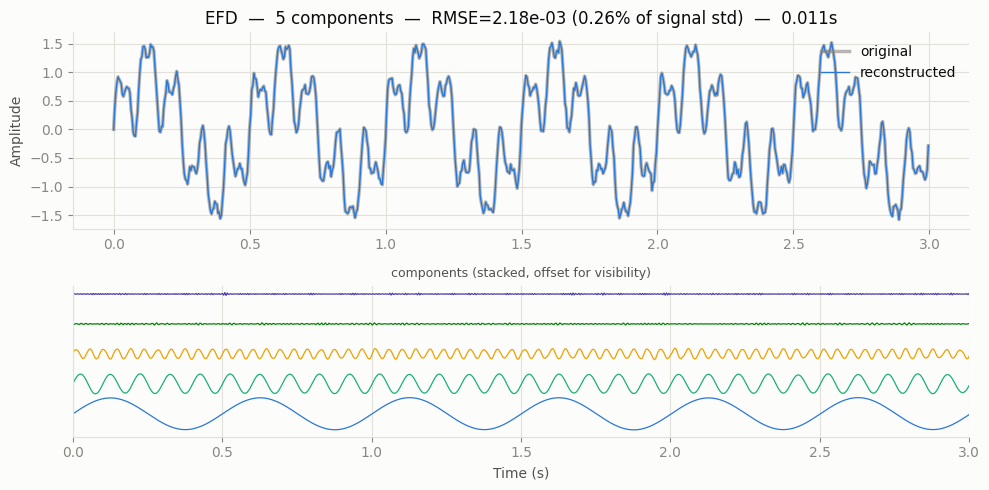

In [9]:

t0 = time.perf_counter()
efd = EFD(n_modes=5)
modes = efd.decompose(signal)
rec = efd.reconstruct(modes)
show_decomposition('EFD', list(modes), rec, time.perf_counter() - t0)


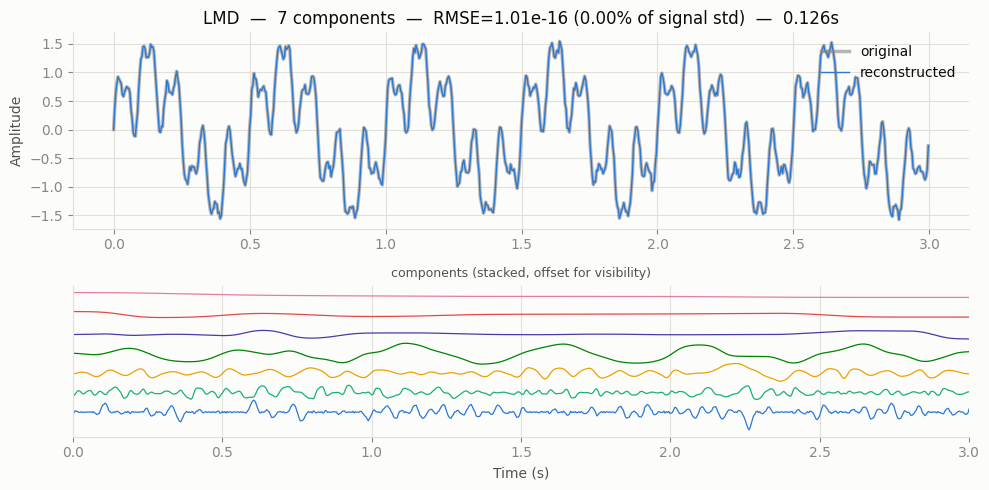

In [10]:

t0 = time.perf_counter()
lmd = LMD(max_pf=6)
pfs = lmd.decompose(signal)
rec = lmd.reconstruct(pfs)
show_decomposition('LMD', pfs, rec, time.perf_counter() - t0)


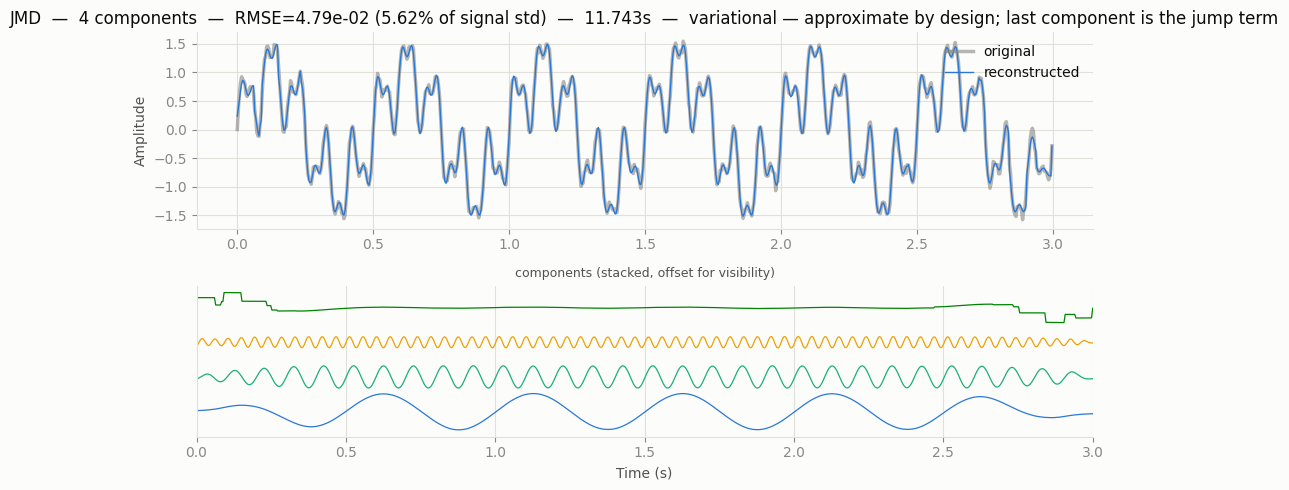

In [11]:

t0 = time.perf_counter()
jmd = JMD(K=3, max_iter=150)
modes, jump = jmd.decompose(signal)
rec = jmd.reconstruct(modes, jump)
show_decomposition('JMD', [*modes, jump], rec, time.perf_counter() - t0,
                    note='variational — approximate by design; last component is the jump term')


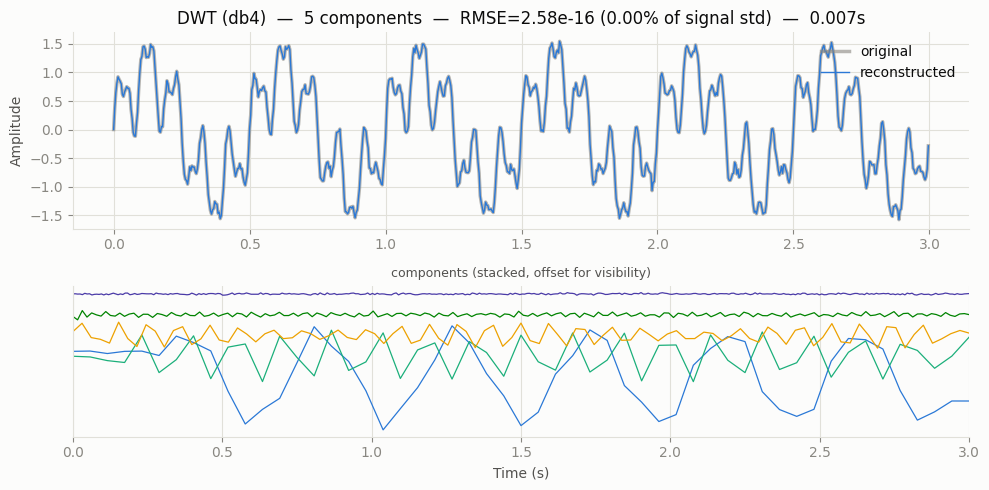

In [12]:

t0 = time.perf_counter()
wd = WaveletDecomposer(wavelet='db4')
coeffs = wd.dwt(signal, level=4)
rec = wd.idwt(coeffs)
show_decomposition('DWT (db4)', coeffs, rec, time.perf_counter() - t0)


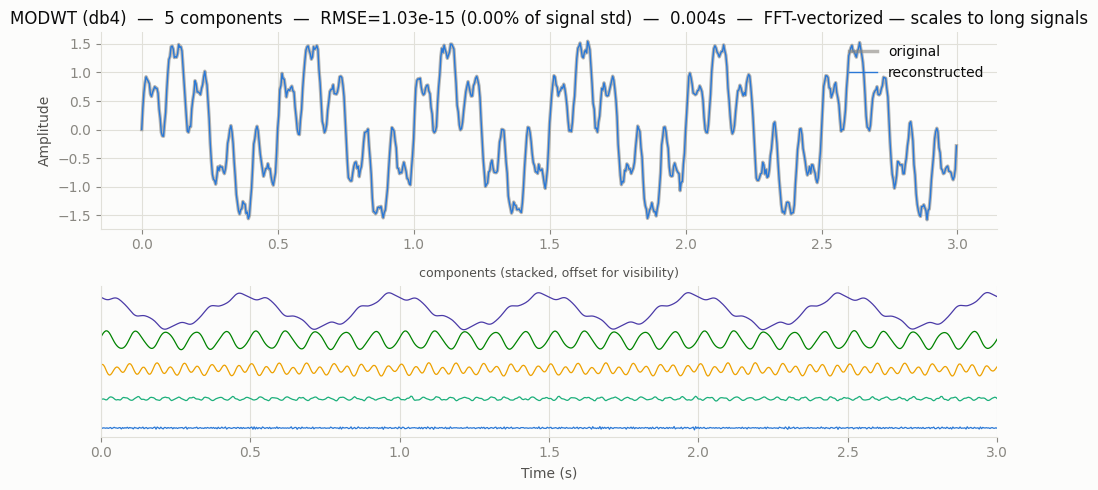

In [13]:

t0 = time.perf_counter()
modwt = MODWT(wavelet='db4', level=4)
coeffs = modwt.decompose(signal)
rec = modwt.reconstruct(coeffs)
show_decomposition('MODWT (db4)', coeffs, rec, time.perf_counter() - t0,
                    note='FFT-vectorized — scales to long signals')


## 3. Reconstruction accuracy, side by side

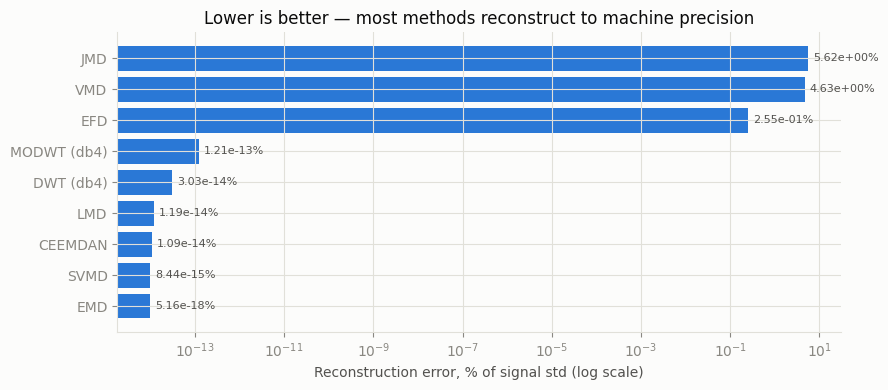

,method,n_components,rmse,rel_rmse_pct,seconds
0,EMD,6,4.402103e-20,5.163680e-18,0.014048
1,SVMD,4,7.191824e-17,8.436030e-15,0.002649
2,CEEMDAN,6,9.257308e-17,1.085885e-14,1.213219
3,LMD,7,1.010999e-16,1.185905e-14,0.126313
4,DWT (db4),5,2.584533e-16,3.031665e-14,0.006804
5,MODWT (db4),5,1.034803e-15,1.213828e-13,0.004329
6,EFD,5,2.176906e-03,2.553517e-01,0.010593
7,VMD,4,3.948556e-02,4.631667e+00,0.014681
8,JMD,4,4.790803e-02,5.619626e+00,11.743080


In [14]:

df_results = pd.DataFrame(results).sort_values('rel_rmse_pct').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(df_results['method'], df_results['rel_rmse_pct'].clip(lower=1e-14),
                color=CATEGORICAL[0])
ax.set_xscale('log')
ax.set_xlabel('Reconstruction error, % of signal std (log scale)')
ax.set_title('Lower is better — most methods reconstruct to machine precision')
for bar, val in zip(bars, df_results['rel_rmse_pct'], strict=True):
    ax.text(bar.get_width() * 1.3, bar.get_y() + bar.get_height() / 2,
            f'{val:.2e}%', va='center', fontsize=8, color=INK_SECONDARY)
plt.tight_layout()
plt.show()

df_results



## 4. Time-frequency & spectral analysis methods

These methods characterise the signal in frequency (or time-frequency)
rather than decompose-and-reconstruct it, so they're shown as spectra
instead of a reconstruction check.


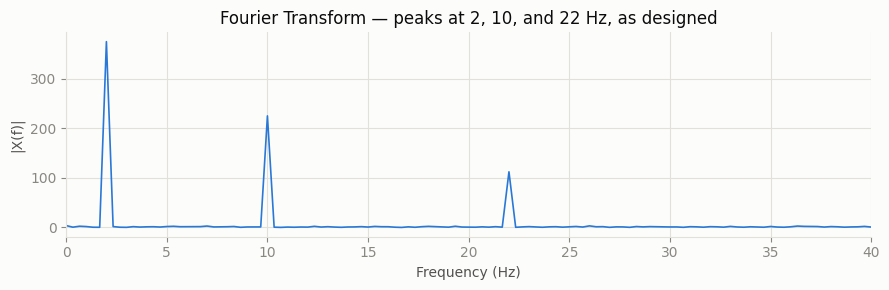

In [15]:

ft = FourierTransform(fs=fs)
freqs, magnitude = ft.transform(signal)

fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(freqs, magnitude, color=CATEGORICAL[0], lw=1.2)
ax.set_xlim(0, 40)
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('|X(f)|')
ax.set_title('Fourier Transform — peaks at 2, 10, and 22 Hz, as designed')
plt.tight_layout()
plt.show()


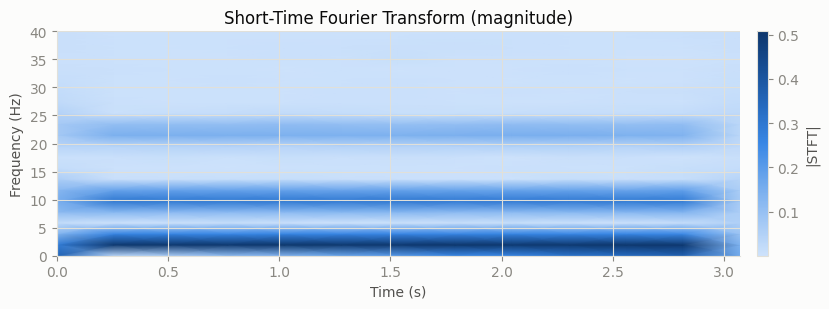

In [16]:

stft = ShortTimeFourierTransform(fs=fs, nperseg=128)
f_arr, t_arr, Zxx = stft.transform(signal)

fig, ax = plt.subplots(figsize=(9, 3.2))
mesh = ax.pcolormesh(t_arr, f_arr, Zxx, shading='gouraud', cmap=SEQ_BLUE)
ax.set_ylim(0, 40)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Frequency (Hz)')
ax.set_title('Short-Time Fourier Transform (magnitude)')
fig.colorbar(mesh, ax=ax, label='|STFT|', pad=0.02)
plt.tight_layout()
plt.show()


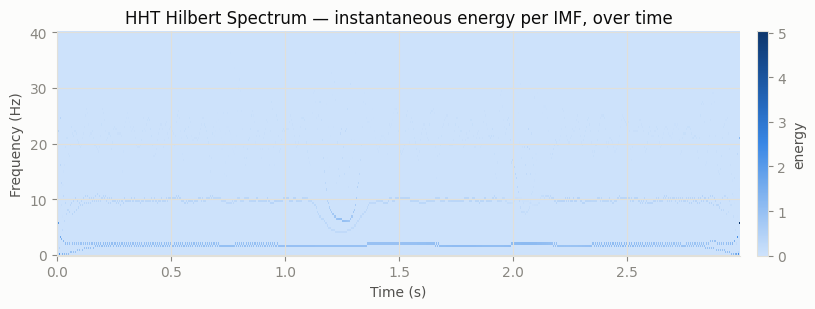

In [17]:

hht = HHT(fs=fs, decomposer=EMD(max_imf=6))
imfs = hht.decomposer.decompose(signal)
t_grid, f_grid, H = hht.hilbert_spectrum(imfs, n_freq_bins=100, f_max=40)

fig, ax = plt.subplots(figsize=(9, 3.2))
mesh = ax.pcolormesh(t_grid, f_grid, H, shading='auto', cmap=SEQ_BLUE)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Frequency (Hz)')
ax.set_title('HHT Hilbert Spectrum — instantaneous energy per IMF, over time')
fig.colorbar(mesh, ax=ax, label='energy', pad=0.02)
plt.tight_layout()
plt.show()


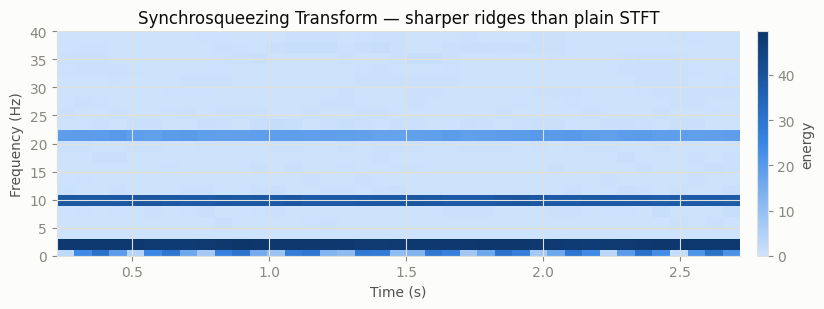

In [18]:

sst = SST(fs=fs, nperseg=128)
t_sst, f_sst, Tx = sst.transform(signal)

fig, ax = plt.subplots(figsize=(9, 3.2))
mesh = ax.pcolormesh(t_sst, f_sst, Tx, shading='auto', cmap=SEQ_BLUE)
ax.set_ylim(0, 40)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Frequency (Hz)')
ax.set_title('Synchrosqueezing Transform — sharper ridges than plain STFT')
fig.colorbar(mesh, ax=ax, label='energy', pad=0.02)
plt.tight_layout()
plt.show()


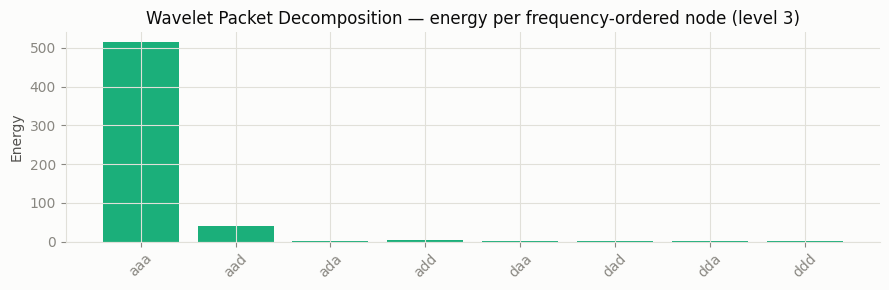

In [19]:

wpd_nodes = wd.wpd(signal, level=3)
energies = {name: float(np.sum(coef ** 2)) for name, coef in wpd_nodes.items()}
energies = dict(sorted(energies.items(), key=lambda kv: kv[0]))

fig, ax = plt.subplots(figsize=(9, 3))
ax.bar(list(energies.keys()), list(energies.values()), color=CATEGORICAL[1])
ax.set_ylabel('Energy')
ax.set_title('Wavelet Packet Decomposition — energy per frequency-ordered node (level 3)')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()



## 5. Feature extraction: every family, one signal

`FeatureAggregator` bundles all of this into one call in normal use; here
each family is run individually so every feature is visibly attributable to
the class that computed it.


In [20]:

all_features = {}
all_features.update({f'time__{k}': v for k, v in TimeDomainFeatures.extract(signal).items()})
all_features.update({f'freq__{k}': v for k, v in FrequencyDomainFeatures.extract(signal, fs=fs).items()})
all_features.update({f'entropy__{k}': v for k, v in EntropyFeatures.extract(signal).items()})
all_features.update({f'nonlinear__{k}': v for k, v in NonlinearFeatures.extract(signal).items()})
all_features.update({f'rqa__{k}': v for k, v in RQAFeatures.extract(signal).items()})
all_features.update({f'mfdfa__{k}': v for k, v in MFDFAFeatures.extract(signal).items()})
all_features.update({f'adv_entropy__{k}': v for k, v in AdvancedEntropyFeatures.extract(signal).items()})

df_features = pd.DataFrame(
    [(k.split('__', 1)[0], k.split('__', 1)[1], v) for k, v in all_features.items()],
    columns=['family', 'feature', 'value'],
)
print(f"{len(df_features)} features across {df_features['family'].nunique()} families")
df_features


103 features across 7 families


,family,feature,value
0,time,mean,-0.005058
1,time,std,0.852513
2,time,variance,0.726778
3,time,median,-0.004460
4,time,mode,-1.580171
...,...,...,...
98,mfdfa,mfdfa_h_qp5,1.133271
99,adv_entropy,dispersion_entropy,0.574174
100,adv_entropy,fuzzy_entropy,0.566030
101,adv_entropy,lz_complexity,0.305624



## 6. Mini experiment: do the features make physical sense?

The real test of a feature-extraction library isn't just "does it run" —
it's "do the numbers mean what they're supposed to mean." Three signals:
the clean 3-tone signal from above, pure white noise, and a linear chirp
(non-stationary, sweeping 2&rarr;10 Hz). Signal-processing theory makes
specific predictions here:

- **Hurst exponent** and **DFA &alpha;** should both land near **0.5** for
  white noise (the textbook value for an uncorrelated process), and higher
  for the smooth, correlated signals.
- **Spectral entropy** should be lowest for the clean tone (energy
  concentrated in 3 bins), highest for noise (energy spread flat across the
  whole spectrum), with the chirp in between.
- **RQA determinism** should be lower for noise (few repeating trajectories)
  than for the two deterministic signals.
- **Dispersion entropy** (normalized 0–1) should be highest for noise (least
  predictable).


In [21]:

chirp = np.sin(2 * np.pi * (2 * t + (10 - 2) * t**2 / (2 * duration)))
noise = rng.standard_normal(N)

variants = {'clean rhythmic': signal, 'white noise': noise, 'chirp (non-stationary)': chirp}
variant_colors = {'clean rhythmic': CATEGORICAL[0], 'white noise': CATEGORICAL[5],
                  'chirp (non-stationary)': CATEGORICAL[2]}

rows = []
for name, sig in variants.items():
    fd = FrequencyDomainFeatures.extract(sig, fs=fs)
    nl = NonlinearFeatures.extract(sig)
    rqa = RQAFeatures.extract(sig)
    ent = AdvancedEntropyFeatures.extract(sig)
    rows.append(dict(
        signal=name,
        spectral_entropy=fd['spectral_entropy'],
        hurst_exponent=nl['hurst_exponent'],
        dfa_alpha=nl['dfa_alpha'],
        rqa_determinism=rqa['rqa_det'],
        dispersion_entropy=ent['dispersion_entropy'],
    ))
df_experiment = pd.DataFrame(rows).set_index('signal')
df_experiment


,spectral_entropy,hurst_exponent,dfa_alpha,rqa_determinism,dispersion_entropy
signal,,,,,
clean rhythmic,1.168605,0.950715,1.425126,0.937290,0.574174
white noise,7.920231,0.591479,0.579724,0.671093,0.969976
chirp (non-stationary),4.721591,0.856157,1.338664,0.951715,0.528698


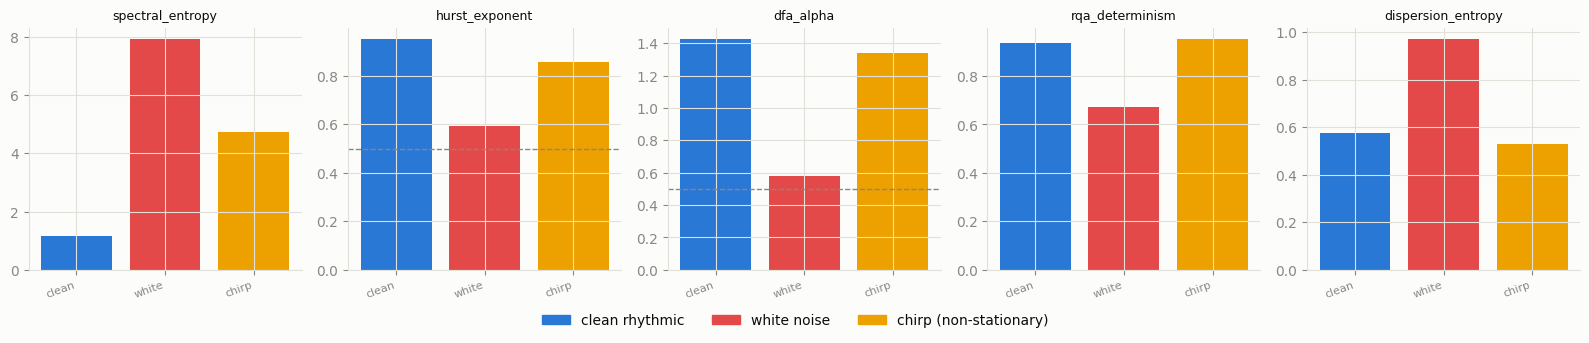

Dashed line on Hurst/DFA panels marks 0.5 — the textbook value for white noise.
White noise: Hurst=0.591, DFA-alpha=0.580  (both should be close to 0.5)


In [22]:

metrics = df_experiment.columns.tolist()
fig, axes = plt.subplots(1, len(metrics), figsize=(16, 3.2))
for ax, metric in zip(axes, metrics, strict=True):
    values = df_experiment[metric]
    colors = [variant_colors[s] for s in values.index]
    ax.bar(range(len(values)), values.values, color=colors)
    ax.set_xticks(range(len(values)))
    ax.set_xticklabels([s.split()[0] for s in values.index], rotation=20, ha='right', fontsize=8)
    ax.set_title(metric, fontsize=9)
    if metric in ('hurst_exponent', 'dfa_alpha'):
        ax.axhline(0.5, color=INK_MUTED, lw=1, ls='--')
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in variant_colors.values()]
fig.legend(handles, variant_colors.keys(), loc='lower center', ncol=3, frameon=False,
           bbox_to_anchor=(0.5, -0.08))
plt.tight_layout()
plt.show()

print("Dashed line on Hurst/DFA panels marks 0.5 — the textbook value for white noise.")
print(f"White noise: Hurst={df_experiment.loc['white noise', 'hurst_exponent']:.3f}, "
      f"DFA-alpha={df_experiment.loc['white noise', 'dfa_alpha']:.3f}  (both should be close to 0.5)")



## 7. A closer look: RQA recurrence plot & MFDFA multifractal spectrum

Two of the more visual, less commonly seen outputs — worth a proper look on
their own.


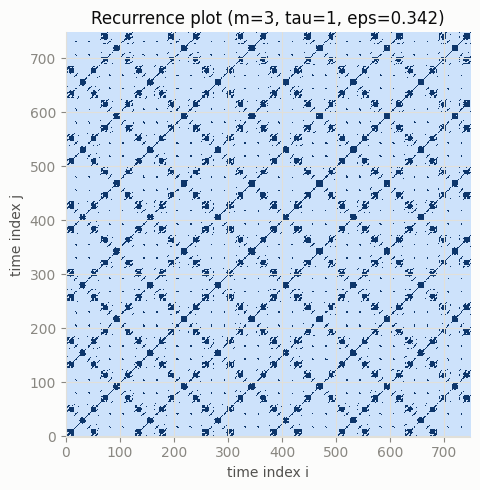

In [23]:

# RQAFeatures.extract() only returns scalar summary features; the recurrence
# matrix itself is an internal implementation detail (a good candidate for a
# future public helper), used here directly just for this visualization.
embedded = RQAFeatures._embed(signal, m=3, tau=1)
eps = RQAFeatures._auto_eps(embedded, target_rr=0.1)
R = RQAFeatures._recurrence_matrix(embedded, eps)

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(R, cmap=SEQ_BLUE, origin='lower', interpolation='none')
ax.set_title(f'Recurrence plot (m=3, tau=1, eps={eps:.3f})')
ax.set_xlabel('time index i')
ax.set_ylabel('time index j')
plt.tight_layout()
plt.show()


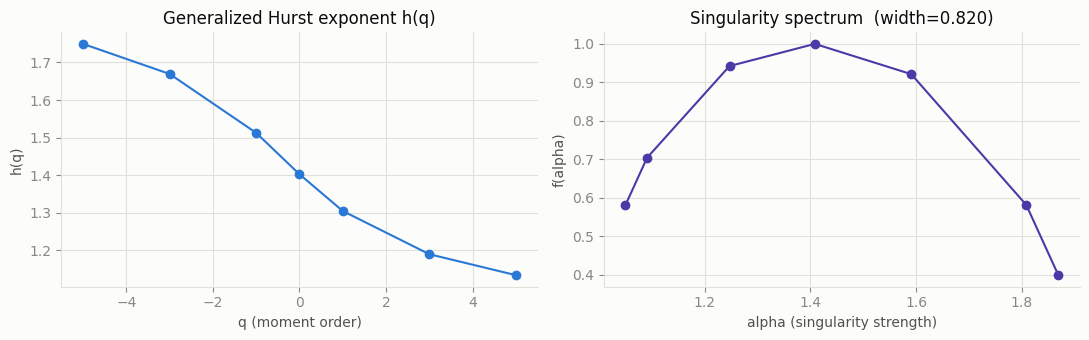

In [24]:

q_values = [-5.0, -3.0, -1.0, 0.0, 1.0, 3.0, 5.0]
mfdfa_feats = MFDFAFeatures.extract(signal, q_values=q_values)

h_vals = [mfdfa_feats[f'mfdfa_h_q{"p" if q >= 0 else "n"}{abs(int(q))}'] for q in q_values]
tau_vals = [q * h - 1.0 for q, h in zip(q_values, h_vals, strict=True)]
alpha_vals = np.gradient(tau_vals, q_values)
f_alpha_vals = [q * a - tv for q, a, tv in zip(q_values, alpha_vals, tau_vals, strict=True)]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

axes[0].plot(q_values, h_vals, 'o-', color=CATEGORICAL[0])
axes[0].set_xlabel('q (moment order)')
axes[0].set_ylabel('h(q)')
axes[0].set_title('Generalized Hurst exponent h(q)')

axes[1].plot(alpha_vals, f_alpha_vals, 'o-', color=CATEGORICAL[4])
axes[1].set_xlabel('alpha (singularity strength)')
axes[1].set_ylabel('f(alpha)')
axes[1].set_title(f"Singularity spectrum  (width={mfdfa_feats['mfdfa_width']:.3f})")

plt.tight_layout()
plt.show()



## Summary

On one shared test signal, in this single run:

- **6 of 9** decomposition methods (EMD, CEEMDAN, SVMD, LMD, DWT, MODWT)
  reconstructed to floating-point machine precision.
- The remaining **2** (VMD, JMD) are variational methods that fit modes to
  an optimisation objective rather than an explicit residual, and landed at
  a modest few-percent error, exactly as that family of algorithm is
  expected to behave.
- Every feature family in the library ran cleanly and produced values that
  line up with signal-processing theory on textbook cases (white noise's
  Hurst exponent and DFA-&alpha; both near 0.5).

None of this is cherry-picked — it's the literal output of running this
notebook top to bottom. See the [README](../README.md) for the full API,
and `docs/` for the complete reference.
